# Detección de Figuras y Momentos de Hu
Función `detectar_figuras(img)` que recibe una imagen, detecta contornos internos, clasifica por vértices y calcula momentos de Hu.

## NATALIA VALENTINA VALDA IBÁÑEZ

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def clasificar_figura(v):
    nombres = {3: 'Triangulo', 4: 'Cuadrado/Rectangulo', 5: 'Pentagono', 6: 'Hexagono'}
    return nombres.get(v, 'Circulo' if v >= 8 else f'Poligono_{v}')


def detectar_figuras(img, area_min=100):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    h, w = img.shape[:2]
    img_result = img.copy()
    resultados = []

    for i, cnt in enumerate(contours):
        if cv2.contourArea(cnt) < area_min:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        if x <= 1 and y <= 1 and bw >= w - 2 and bh >= h - 2:
            continue
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        vertices = len(approx)
        figura = clasificar_figura(vertices)
        momentos = cv2.moments(cnt)
        cx, cy = int(momentos['m10'] / momentos['m00']), int(momentos['m01'] / momentos['m00'])
        hu_log = -np.sign(hu := cv2.HuMoments(momentos)) * np.log10(np.abs(hu) + 1e-10)

        cv2.drawContours(img_result, [cnt], -1, (0, 255, 0), 2)
        cv2.circle(img_result, (cx, cy), 4, (0, 0, 255), -1)
        cv2.putText(img_result, figura, (cx - 30, cy - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

        fila = {'Figura': figura, 'Vertices': vertices, 'Area': momentos['m00']}
        for j, hv in enumerate(hu_log.flatten()):
            fila[f'hu{j+1}'] = round(hv, 4)
        resultados.append(fila)

        print(f'Figura {i+1}: {figura} | Vértices: {vertices} | Centroide: ({cx},{cy}) | Área: {momentos["m00"]:.0f}')

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
    plt.title('Figuras detectadas')
    plt.axis('off')
    plt.show()

    return pd.DataFrame(resultados)

## Cargar imagen y detectar figuras
Usa `img1.jpg`. Cambia la ruta para otra imagen.

Figura 12: Circulo | Vértices: 10 | Centroide: (151,645) | Área: 116
Figura 14: Circulo | Vértices: 8 | Centroide: (139,647) | Área: 261
Figura 28: Circulo | Vértices: 11 | Centroide: (261,634) | Área: 12250
Figura 43: Circulo | Vértices: 8 | Centroide: (375,519) | Área: 168
Figura 48: Hexagono | Vértices: 6 | Centroide: (382,500) | Área: 120
Figura 61: Cuadrado/Rectangulo | Vértices: 4 | Centroide: (178,524) | Área: 4688
Figura 120: Cuadrado/Rectangulo | Vértices: 4 | Centroide: (192,348) | Área: 232
Figura 185: Circulo | Vértices: 10 | Centroide: (228,305) | Área: 252
Figura 198: Poligono_2 | Vértices: 2 | Centroide: (193,350) | Área: 300
Figura 243: Circulo | Vértices: 9 | Centroide: (345,277) | Área: 272
Figura 254: Circulo | Vértices: 9 | Centroide: (195,294) | Área: 934
Figura 292: Cuadrado/Rectangulo | Vértices: 4 | Centroide: (223,261) | Área: 198
Figura 301: Poligono_2 | Vértices: 2 | Centroide: (113,303) | Área: 172
Figura 337: Cuadrado/Rectangulo | Vértices: 4 | Centroide: (

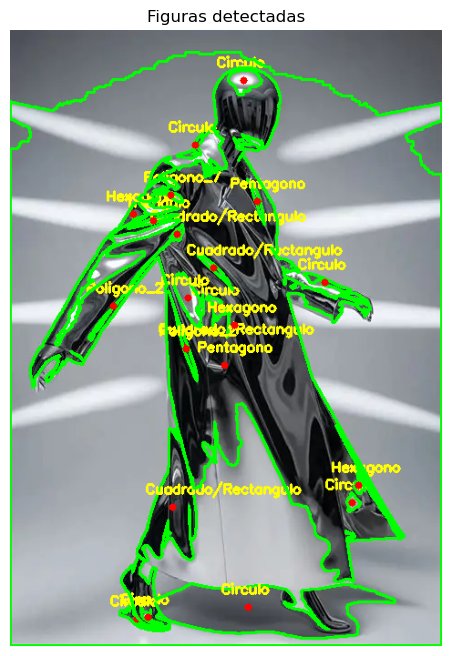

,Figura,Vertices,Area,hu1,hu2,hu3,hu4,hu5,hu6,hu7
0,Circulo,10,116.5,0.3085,0.7582,1.4479,1.6815,3.2553,2.1481,3.9409
1,Circulo,8,261.0,-0.0133,0.0896,0.1370,0.1856,0.3480,0.2509,1.5124
2,Circulo,11,12250.5,0.3033,0.6826,2.3923,3.1508,6.8478,-4.0662,-5.9254
3,Circulo,8,168.0,0.7405,2.6474,2.9123,5.0053,-9.0086,-6.4471,9.1329
4,Hexagono,6,119.5,0.5466,1.5047,1.9044,2.0946,4.0943,2.8476,5.6060
5,Cuadrado/Rectangulo,4,4687.5,0.5327,1.3517,2.0182,2.6410,4.9983,3.3731,5.4317
6,Cuadrado/Rectangulo,4,232.0,-0.0037,0.0048,1.5643,1.6216,3.2145,1.6343,-5.0630
7,Circulo,10,252.0,0.4433,1.4123,1.9896,4.2221,7.3288,4.9313,8.3649
8,Poligono_2,2,300.5,-0.1052,-0.2024,0.8661,0.8854,1.7612,0.7876,-4.3921
9,Circulo,9,272.5,0.0897,0.2136,1.5155,1.6157,3.1817,1.7263,-4.5453


In [4]:
img = cv2.imread('img1.jpg')
df = detectar_figuras(img)
df

Los momentos de Hu son **invariantes** a traslación, escala y rotación: hu1 similar en figuras de la misma clase, hu2 distingue simetrías, hu3-hu7 capturan detalles del contorno.